# Uprighting Velocity and Rotational Timing

## Research question

How quickly do hitters extend the torso and posteriorly tilt the pelvis between front-foot plant and contact, and when do those peak posture-change rates occur relative to peak axial rotation?

This study extends the posture analysis from Notebook 04. The previous notebook asked **how much** posture changed and whether that change related to contact-point consistency. This notebook asks **how fast** posture changed and **when** that change occurred within the rotational sequence.

### Primary outputs

- Peak torso uprighting velocity (degrees/second)
- Peak pelvis posterior-tilt velocity (degrees/second)
- Timing of each peak after front-foot plant
- Timing offset from the corresponding peak axial-rotation velocity

### Secondary, exploratory questions

At the athlete-session level, are torso peak uprighting velocity or torso uprighting-versus-rotation timing associated with bat speed, exit velocity, or attack angle?

The analysis is observational. “Uprighting” describes positive torso extension under the OpenBiomechanics convention; it is not automatically a mechanical fault, and the results do not establish causal coaching prescriptions.

In [1]:
from pathlib import Path
import hashlib
import sys
import zipfile
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
from scipy.signal import butter, sosfiltfilt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

RANDOM_SEED = 20260917
MIN_SWINGS_PER_SESSION = 5
MIN_PLANT_TO_CONTACT_SECONDS = 0.080
MAX_PLANT_TO_CONTACT_SECONDS = 0.200
FILTER_CUTOFF_HZ = 12
FILTER_ORDER = 4
SENSITIVITY_CUTOFFS_HZ = (8, 16)
N_BOOTSTRAPS = 5000
COUPLED_WINDOW_MS = 20

PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd(), *Path.cwd().parents]
        if (path / "src" / "obp_utils.py").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root. Open this notebook from inside "
        "the baseball-biomechanics-analysis repository."
    )

sys.path.insert(0, str(PROJECT_ROOT / "src"))
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "hitting"

## Data preparation

The notebook uses the official Dataset v1 full-signal hitting joint-angle and joint-velocity tables, plus metadata and point-of-interest metrics. It downloads missing files from the OpenBiomechanics release and verifies the two large archives against their published SHA-256 digests.

In [2]:
JOINT_ANGLES_URL = (
    "https://github.com/drivelineresearch/openbiomechanics/releases/download/"
    "dataset-v1/hitting_joint_angles.zip"
)
JOINT_ANGLES_SHA256 = (
    "98a405c5c4a27c1a599d3e30b39a3087180cc4d4bb69faf62204a1c06881be95"
)
JOINT_VELOS_URL = (
    "https://github.com/drivelineresearch/openbiomechanics/releases/download/"
    "dataset-v1/hitting_joint_velos.zip"
)
JOINT_VELOS_SHA256 = (
    "3822dbce30988bc554ee533e5ccc12a5a3e92a53e185fdcb1cc8ad218dd464e4"
)
METADATA_URL = (
    "https://raw.githubusercontent.com/drivelineresearch/openbiomechanics/"
    "dataset-v1/baseball_hitting/data/metadata.csv"
)
POI_URL = (
    "https://raw.githubusercontent.com/drivelineresearch/openbiomechanics/"
    "dataset-v1/baseball_hitting/data/poi/poi_metrics.csv"
)


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def download_csv_if_missing(url, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists():
        print(f"Downloading {path.name}...")
        urlretrieve(url, path)
    return path


def download_and_extract_if_missing(url, expected_hash, csv_name):
    output_path = RAW_DIR / csv_name
    if output_path.exists():
        return output_path

    RAW_DIR.mkdir(parents=True, exist_ok=True)
    archive_path = RAW_DIR / f"{Path(csv_name).stem}.zip"

    if not archive_path.exists():
        print(f"Downloading {archive_path.name}...")
        urlretrieve(url, archive_path)

    actual_hash = sha256_file(archive_path)
    if actual_hash != expected_hash:
        raise ValueError(
            f"Checksum mismatch for {archive_path.name}. "
            f"Expected {expected_hash}, got {actual_hash}."
        )

    with zipfile.ZipFile(archive_path) as compressed:
        matches = [
            member for member in compressed.namelist()
            if Path(member).name == csv_name
        ]
        if len(matches) != 1:
            raise ValueError(
                f"Expected one {csv_name} file in {archive_path.name}, "
                f"found {len(matches)}."
            )
        with compressed.open(matches[0]) as source, output_path.open("wb") as target:
            target.write(source.read())

    return output_path


joint_angles_path = download_and_extract_if_missing(
    JOINT_ANGLES_URL,
    JOINT_ANGLES_SHA256,
    "joint_angles.csv",
)
joint_velos_path = download_and_extract_if_missing(
    JOINT_VELOS_URL,
    JOINT_VELOS_SHA256,
    "joint_velos.csv",
)
metadata_path = download_csv_if_missing(METADATA_URL, RAW_DIR / "metadata.csv")
poi_path = download_csv_if_missing(POI_URL, RAW_DIR / "poi_metrics.csv")

print("Joint angles:    ", joint_angles_path)
print("Joint velocities:", joint_velos_path)
print("Metadata:        ", metadata_path)
print("POI metrics:     ", poi_path)

In [3]:
angle_columns = [
    "session_swing",
    "time",
    "pelvis_angle_x",
    "torso_angle_x",
    "fp_100_time",
    "contact_time",
]
velocity_columns = [
    "session_swing",
    "time",
    "pelvis_angular_velocity_z",
    "torso_angular_velocity_z",
]
metadata_columns = [
    "session_swing",
    "user",
    "session",
    "hitter_side",
    "athlete_age",
    "highest_playing_level",
]
poi_columns = [
    "session_swing",
    "exit_velo_mph_x",
    "bat_speed_mph_contact_x",
    "attack_angle_contact_x",
]

angles = pd.read_csv(
    joint_angles_path,
    usecols=angle_columns,
    dtype={"session_swing": str},
)
velocities = pd.read_csv(
    joint_velos_path,
    usecols=velocity_columns,
    dtype={"session_swing": str},
)
metadata = pd.read_csv(
    metadata_path,
    usecols=metadata_columns,
    dtype={"session_swing": str, "user": str, "session": str},
)
poi = pd.read_csv(
    poi_path,
    usecols=poi_columns,
    dtype={"session_swing": str},
)

for name, frame in [("metadata", metadata), ("POI", poi)]:
    if frame["session_swing"].duplicated().any():
        raise ValueError(f"{name} contains duplicate session_swing keys.")

kinematics = angles.merge(
    velocities,
    on=["session_swing", "time"],
    how="inner",
    validate="one_to_one",
).merge(
    metadata,
    on="session_swing",
    how="left",
    validate="many_to_one",
)

if kinematics["user"].isna().any():
    raise ValueError("Some full-signal rows did not match metadata.")

sampling_interval = (
    kinematics.groupby("session_swing", sort=False)["time"].diff().median()
)

print(f"Full-signal rows: {len(kinematics):,}")
print(f"Swing trials:     {kinematics['session_swing'].nunique():,}")
print(f"Athletes:         {kinematics['user'].nunique():,}")
print(f"Median interval:  {sampling_interval:.4f} seconds")
print(f"Approx. rate:     {1 / sampling_interval:.1f} Hz")

## Metric definitions

OpenBiomechanics defines the full-signal axes as follows:

- **Torso X:** extension (+) / flexion (-)
- **Pelvis X:** posterior (+) / anterior (-) tilt
- **Torso and pelvis Z angular velocity:** axial rotation toward the mound (+)

For each swing, X-angle signals are low-pass filtered with a fourth-order, zero-phase Butterworth filter at 12 Hz. Uprighting/posture-change velocity is the numerical first derivative of the filtered X angle in degrees per second.

Peaks are extracted between front-foot plant and contact. Trials are retained only when this interval is 80–200 ms, which removes missing, reversed, and unusually short event windows where a derivative peak would be dominated by the analysis boundary. The timing offset is:

$$\text{uprighting peak time} - \text{axial-rotation peak time}$$

Negative values indicate that peak uprighting occurred first; positive values indicate that peak axial rotation occurred first. Peaks within ±20 ms are summarized as closely coupled for descriptive purposes.

In [4]:
def classify_event_window(plant_time, contact_time):
    if pd.isna(plant_time) or pd.isna(contact_time):
        return "Missing plant/contact event"

    duration = float(contact_time) - float(plant_time)
    if duration <= 0:
        return "Contact at/before plant"
    if duration < MIN_PLANT_TO_CONTACT_SECONDS:
        return "Plant-to-contact < 80 ms"
    if duration > MAX_PLANT_TO_CONTACT_SECONDS:
        return "Plant-to-contact > 200 ms"
    return "Retained"


event_rows = (
    kinematics.groupby("session_swing", sort=False)
    .agg(
        fp_100_time=("fp_100_time", "first"),
        contact_time=("contact_time", "first"),
    )
    .reset_index()
)
event_rows["status"] = [
    classify_event_window(plant, contact)
    for plant, contact in zip(
        event_rows["fp_100_time"],
        event_rows["contact_time"],
    )
]

event_qc = (
    event_rows["status"]
    .value_counts(dropna=False)
    .rename_axis("event-window status")
    .reset_index(name="swings")
)
display(event_qc)

,event-window status,swings
0,Retained,615
1,Plant-to-contact < 80 ms,28
2,Missing plant/contact event,25
3,Contact at/before plant,9


In [5]:
def filtered_angle_and_rate(time, angle, cutoff_hz):
    time = np.asarray(time, dtype=float)
    angle = np.asarray(angle, dtype=float)

    if not np.isfinite(time).all() or not np.isfinite(angle).all():
        raise ValueError("Non-finite time or angle values were found.")

    dt = float(np.median(np.diff(time)))
    if dt <= 0:
        raise ValueError("Time must increase within each swing.")

    sampling_rate = 1 / dt
    sos = butter(
        FILTER_ORDER,
        cutoff_hz,
        btype="low",
        fs=sampling_rate,
        output="sos",
    )
    filtered_angle = sosfiltfilt(sos, angle)
    angle_rate = np.gradient(filtered_angle, time)
    return filtered_angle, angle_rate


def nearest_index(time, target):
    return int(np.abs(np.asarray(time, dtype=float) - float(target)).argmin())


def extract_swing_features(group, cutoff_hz=FILTER_CUTOFF_HZ):
    group = group.sort_values("time").reset_index(drop=True)
    plant_time = group["fp_100_time"].iloc[0]
    contact_time = group["contact_time"].iloc[0]

    if classify_event_window(plant_time, contact_time) != "Retained":
        return None

    time = group["time"].to_numpy(dtype=float)
    analysis_mask = (time >= plant_time) & (time <= contact_time)
    analysis_indices = np.flatnonzero(analysis_mask)

    if len(analysis_indices) < 20:
        return None

    plant_index = nearest_index(time, plant_time)
    contact_index = nearest_index(time, contact_time)
    result = {
        "session_swing": str(group["session_swing"].iloc[0]),
        "user": str(group["user"].iloc[0]),
        "session": str(group["session"].iloc[0]),
        "hitter_side": group["hitter_side"].iloc[0],
        "athlete_age": group["athlete_age"].iloc[0],
        "highest_playing_level": group["highest_playing_level"].iloc[0],
        "plant_to_contact_ms": 1000 * (float(contact_time) - float(plant_time)),
    }

    for segment in ["pelvis", "torso"]:
        filtered_angle, angle_rate = filtered_angle_and_rate(
            time,
            group[f"{segment}_angle_x"].to_numpy(dtype=float),
            cutoff_hz,
        )

        peak_upright_index = analysis_indices[
            np.argmax(angle_rate[analysis_mask])
        ]
        rotation_velocity = group[
            f"{segment}_angular_velocity_z"
        ].to_numpy(dtype=float)
        rotation_window = rotation_velocity[analysis_mask]

        if not np.isfinite(rotation_window).any():
            return None

        peak_rotation_index = analysis_indices[
            np.nanargmax(rotation_window)
        ]

        result.update(
            {
                f"peak_{segment}_uprighting_dps": float(
                    angle_rate[peak_upright_index]
                ),
                f"{segment}_uprighting_peak_ms": 1000
                * (float(time[peak_upright_index]) - float(plant_time)),
                f"{segment}_rotation_peak_ms": 1000
                * (float(time[peak_rotation_index]) - float(plant_time)),
                f"{segment}_uprighting_minus_rotation_ms": 1000
                * (
                    float(time[peak_upright_index])
                    - float(time[peak_rotation_index])
                ),
                f"{segment}_angle_change_deg": float(
                    filtered_angle[contact_index]
                    - filtered_angle[plant_index]
                ),
                f"{segment}_uprighting_at_contact_dps": float(
                    angle_rate[contact_index]
                ),
            }
        )

    return result


swing_features = pd.DataFrame(
    [
        record
        for _, group in kinematics.groupby("session_swing", sort=False)
        if (record := extract_swing_features(group)) is not None
    ]
)

if swing_features.empty:
    raise ValueError("No swings met the event and signal-quality requirements.")

print(f"Retained swings:   {len(swing_features):,}")
print(f"Retained athletes: {swing_features['user'].nunique():,}")
display(swing_features.head().round(3))

,session_swing,user,session,hitter_side,athlete_age,highest_playing_level,plant_to_contact_ms,peak_pelvis_uprighting_dps,pelvis_uprighting_peak_ms,pelvis_rotation_peak_ms,pelvis_uprighting_minus_rotation_ms,pelvis_angle_change_deg,pelvis_uprighting_at_contact_dps,peak_torso_uprighting_dps,torso_uprighting_peak_ms,torso_rotation_peak_ms,torso_uprighting_minus_rotation_ms,torso_angle_change_deg,torso_uprighting_at_contact_dps
0,103_1,000004,000103,R,18,high_school,158.400,277.054,86.200,41.700,44.500,26.837,88.430,378.516,111.200,83.400,27.800,41.758,115.141
1,103_2,000004,000103,R,18,high_school,147.200,277.219,94.400,44.400,50.000,29.090,133.978,403.975,105.600,63.900,41.700,42.411,165.183
2,103_3,000004,000103,R,18,high_school,169.400,216.914,105.600,41.700,63.900,23.952,107.017,322.845,105.600,100.000,5.600,42.154,149.951
3,103_4,000004,000103,R,18,high_school,158.300,251.738,97.200,44.500,52.700,24.834,75.138,351.584,80.600,83.300,-2.700,41.454,196.062
4,103_5,000004,000103,R,18,high_school,152.700,219.618,77.700,36.100,41.600,25.663,147.040,306.433,52.700,75.000,-22.300,38.053,103.167


## Peak speed and timing results

In [6]:
descriptive_columns = {
    "peak_torso_uprighting_dps": "Peak torso uprighting (deg/s)",
    "torso_uprighting_peak_ms": "Torso peak after plant (ms)",
    "torso_rotation_peak_ms": "Torso rotation peak after plant (ms)",
    "torso_uprighting_minus_rotation_ms": "Torso upright - rotation (ms)",
    "torso_angle_change_deg": "Torso angle change (deg)",
    "peak_pelvis_uprighting_dps": "Peak pelvis posterior tilt (deg/s)",
    "pelvis_uprighting_peak_ms": "Pelvis peak after plant (ms)",
    "pelvis_rotation_peak_ms": "Pelvis rotation peak after plant (ms)",
    "pelvis_uprighting_minus_rotation_ms": "Pelvis posture - rotation (ms)",
    "pelvis_angle_change_deg": "Pelvis angle change (deg)",
}

descriptive_rows = []
for column, label in descriptive_columns.items():
    values = swing_features[column].dropna()
    descriptive_rows.append(
        {
            "metric": label,
            "mean": values.mean(),
            "sd": values.std(ddof=1),
            "p10": values.quantile(0.10),
            "median": values.median(),
            "p90": values.quantile(0.90),
        }
    )

descriptive_table = pd.DataFrame(descriptive_rows)
display(descriptive_table.round(2))


def timing_group(offset_ms):
    if offset_ms < -COUPLED_WINDOW_MS:
        return f"Uprighting leads by >{COUPLED_WINDOW_MS} ms"
    if offset_ms > COUPLED_WINDOW_MS:
        return f"Uprighting lags by >{COUPLED_WINDOW_MS} ms"
    return f"Peaks within ±{COUPLED_WINDOW_MS} ms"


timing_rows = []
for segment in ["torso", "pelvis"]:
    groups = swing_features[
        f"{segment}_uprighting_minus_rotation_ms"
    ].map(timing_group)
    percentages = 100 * groups.value_counts(normalize=True)
    for label in [
        f"Uprighting leads by >{COUPLED_WINDOW_MS} ms",
        f"Peaks within ±{COUPLED_WINDOW_MS} ms",
        f"Uprighting lags by >{COUPLED_WINDOW_MS} ms",
    ]:
        timing_rows.append(
            {
                "segment": segment.title(),
                "timing classification": label,
                "swings": int((groups == label).sum()),
                "percent": percentages.get(label, 0.0),
            }
        )

timing_table = pd.DataFrame(timing_rows)
display(timing_table.round(1))

,metric,mean,sd,p10,median,p90
0,Peak torso uprighting (deg/s),485.980,104.850,354.100,484.260,630.240
1,Torso peak after plant (ms),90.230,26.180,52.800,94.400,119.400
2,Torso rotation peak after plant (ms),57.620,17.300,38.900,55.600,79.420
3,Torso upright - rotation (ms),32.610,20.310,5.600,33.300,58.400
4,Torso angle change (deg),43.150,7.920,32.500,44.150,52.450
5,Peak pelvis posterior tilt (deg/s),360.330,65.150,280.640,353.030,447.600
6,Pelvis peak after plant (ms),72.840,17.850,52.700,72.300,93.320
7,Pelvis rotation peak after plant (ms),55.240,22.090,30.500,52.800,86.100
8,Pelvis posture - rotation (ms),17.600,21.270,-8.360,16.700,44.400
9,Pelvis angle change (deg),30.300,6.160,22.900,29.820,39.160


,segment,timing classification,swings,percent
0,Torso,Uprighting leads by >20 ms,6,1.000
1,Torso,Peaks within ±20 ms,161,26.200
2,Torso,Uprighting lags by >20 ms,448,72.800
3,Pelvis,Uprighting leads by >20 ms,22,3.600
4,Pelvis,Peaks within ±20 ms,344,55.900
5,Pelvis,Uprighting lags by >20 ms,249,40.500


## Athlete-session aggregation and exploratory outcomes

Swing-level measurements from the same athlete are not independent. The outcome analysis therefore averages mechanics and performance within athlete-session and retains groups with at least five complete swings. Associations use Spearman correlations, athlete-level bootstrap confidence intervals, and Benjamini–Hochberg false-discovery-rate adjustment across the six specified comparisons.

In [7]:
swing_data = swing_features.merge(
    poi,
    on="session_swing",
    how="left",
    validate="one_to_one",
)


def summarize_session(group):
    return {
        "user": str(group["user"].iloc[0]),
        "session": str(group["session"].iloc[0]),
        "hitter_side": group["hitter_side"].iloc[0],
        "swings": len(group),
        "peak_torso_uprighting_mean_dps": group[
            "peak_torso_uprighting_dps"
        ].mean(),
        "peak_torso_uprighting_sd_dps": group[
            "peak_torso_uprighting_dps"
        ].std(ddof=1),
        "torso_uprighting_minus_rotation_mean_ms": group[
            "torso_uprighting_minus_rotation_ms"
        ].mean(),
        "torso_uprighting_minus_rotation_sd_ms": group[
            "torso_uprighting_minus_rotation_ms"
        ].std(ddof=1),
        "peak_pelvis_uprighting_mean_dps": group[
            "peak_pelvis_uprighting_dps"
        ].mean(),
        "pelvis_uprighting_minus_rotation_mean_ms": group[
            "pelvis_uprighting_minus_rotation_ms"
        ].mean(),
        "exit_velo_mean_mph": group["exit_velo_mph_x"].mean(),
        "bat_speed_mean_mph": group["bat_speed_mph_contact_x"].mean(),
        "attack_angle_mean_deg": group["attack_angle_contact_x"].mean(),
    }


session_summary = pd.DataFrame(
    [
        summarize_session(group)
        for _, group in swing_data.groupby(["user", "session"], sort=False)
        if len(group) >= MIN_SWINGS_PER_SESSION
    ]
)

if session_summary.empty:
    raise ValueError("No athlete-sessions met the minimum swing requirement.")

print(
    f"Retained athlete-sessions: {len(session_summary):,} "
    f"from {session_summary['user'].nunique():,} athletes"
)
display(session_summary.head(10).round(3))

,user,session,hitter_side,swings,peak_torso_uprighting_mean_dps,peak_torso_uprighting_sd_dps,torso_uprighting_minus_rotation_mean_ms,torso_uprighting_minus_rotation_sd_ms,peak_pelvis_uprighting_mean_dps,pelvis_uprighting_minus_rotation_mean_ms,exit_velo_mean_mph,bat_speed_mean_mph,attack_angle_mean_deg
0,000004,000103,R,5,352.670,39.777,10.020,25.227,248.509,50.540,89.920,64.855,4.569
1,000010,000111,L,8,477.894,22.439,27.063,15.356,355.085,9.375,81.838,62.468,5.896
2,000022,000121,R,7,444.256,35.098,29.329,7.860,281.226,7.957,94.729,68.681,13.169
3,000009,000123,R,9,380.723,56.971,28.389,11.763,290.040,2.156,73.978,52.467,5.227
4,000024,000125,L,7,473.771,29.593,5.571,5.765,343.535,19.057,90.443,67.946,8.451
5,000037,000140,R,8,497.337,34.429,28.113,10.209,301.780,12.137,91.688,67.441,-0.187
6,000051,000160,R,8,677.784,91.002,27.075,6.057,449.800,12.850,80.200,58.785,0.493
7,000054,000164,L,9,416.802,27.815,22.511,18.067,316.139,53.678,95.089,70.503,7.738
8,000056,000167,R,8,679.765,55.925,46.188,5.922,515.106,16.000,93.700,72.969,8.857
9,000059,000017,R,5,481.724,75.750,49.420,7.207,328.747,15.020,97.380,68.456,9.960


In [8]:
def athlete_bootstrap_spearman(
    data,
    x_column,
    y_column,
    n_boot=N_BOOTSTRAPS,
    seed=RANDOM_SEED,
):
    valid = data[[x_column, y_column, "user"]].dropna().copy()

    if (
        len(valid) < 3
        or valid[x_column].nunique() < 2
        or valid[y_column].nunique() < 2
    ):
        return {
            "sessions": len(valid),
            "athletes": valid["user"].nunique(),
            "spearman_rho": np.nan,
            "p_value": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        }

    rho, p_value = stats.spearmanr(valid[x_column], valid[y_column])
    athlete_ids = valid["user"].unique()
    athlete_arrays = [
        valid.loc[
            valid["user"].eq(athlete_id),
            [x_column, y_column],
        ].to_numpy(dtype=float)
        for athlete_id in athlete_ids
    ]
    rng = np.random.default_rng(seed)
    bootstrap_values = []

    for _ in range(n_boot):
        sampled_positions = rng.integers(
            0,
            len(athlete_arrays),
            size=len(athlete_arrays),
        )
        draw = np.concatenate(
            [athlete_arrays[position] for position in sampled_positions],
            axis=0,
        )

        if len(np.unique(draw[:, 0])) < 2 or len(np.unique(draw[:, 1])) < 2:
            continue

        draw_rho, _ = stats.spearmanr(draw[:, 0], draw[:, 1])
        if pd.notna(draw_rho):
            bootstrap_values.append(draw_rho)

    ci_low, ci_high = (
        np.quantile(bootstrap_values, [0.025, 0.975])
        if bootstrap_values
        else (np.nan, np.nan)
    )

    return {
        "sessions": len(valid),
        "athletes": valid["user"].nunique(),
        "spearman_rho": rho,
        "p_value": p_value,
        "ci_low": ci_low,
        "ci_high": ci_high,
    }


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p_values, np.nan)
    valid_indices = np.flatnonzero(np.isfinite(p_values))
    if len(valid_indices) == 0:
        return adjusted

    order = valid_indices[np.argsort(p_values[valid_indices])]
    ranked = p_values[order] * len(order) / np.arange(1, len(order) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted[order] = np.clip(ranked, 0, 1)
    return adjusted


relationships = [
    (
        "Peak torso uprighting → bat speed",
        "peak_torso_uprighting_mean_dps",
        "bat_speed_mean_mph",
    ),
    (
        "Peak torso uprighting → exit velocity",
        "peak_torso_uprighting_mean_dps",
        "exit_velo_mean_mph",
    ),
    (
        "Peak torso uprighting → attack angle",
        "peak_torso_uprighting_mean_dps",
        "attack_angle_mean_deg",
    ),
    (
        "Torso upright-rotation offset → bat speed",
        "torso_uprighting_minus_rotation_mean_ms",
        "bat_speed_mean_mph",
    ),
    (
        "Torso upright-rotation offset → exit velocity",
        "torso_uprighting_minus_rotation_mean_ms",
        "exit_velo_mean_mph",
    ),
    (
        "Torso upright-rotation offset → attack angle",
        "torso_uprighting_minus_rotation_mean_ms",
        "attack_angle_mean_deg",
    ),
]

relationship_rows = []
for index, (label, x_column, y_column) in enumerate(relationships):
    result = athlete_bootstrap_spearman(
        session_summary,
        x_column,
        y_column,
        seed=RANDOM_SEED + index,
    )
    relationship_rows.append({"relationship": label, **result})

relationship_results = pd.DataFrame(relationship_rows)
relationship_results["fdr_q_value"] = benjamini_hochberg(
    relationship_results["p_value"]
)
display(relationship_results.round(3))

,relationship,sessions,athletes,spearman_rho,p_value,ci_low,ci_high,fdr_q_value
0,Peak torso uprighting → bat speed,84,84,0.107,0.331,-0.111,0.330,0.497
1,Peak torso uprighting → exit velocity,83,83,-0.011,0.925,-0.225,0.201,0.925
2,Peak torso uprighting → attack angle,84,84,-0.073,0.510,-0.294,0.155,0.612
3,Torso upright-rotation offset → bat speed,84,84,0.284,0.009,0.088,0.454,0.053
4,Torso upright-rotation offset → exit velocity,83,83,0.128,0.249,-0.068,0.311,0.497
5,Torso upright-rotation offset → attack angle,84,84,-0.140,0.205,-0.352,0.096,0.497


## Filter sensitivity

Differentiation amplifies noise, so the primary 12 Hz results are compared with otherwise identical 8 Hz and 16 Hz pipelines. Rank-order agreement, median peak-speed shift, median absolute timing change, and three-category timing agreement are reported.

In [9]:
sensitivity_rows = []
primary_for_sensitivity = swing_features[
    [
        "session_swing",
        "peak_torso_uprighting_dps",
        "torso_uprighting_minus_rotation_ms",
    ]
].copy()

for cutoff_hz in SENSITIVITY_CUTOFFS_HZ:
    alternate = pd.DataFrame(
        [
            record
            for _, group in kinematics.groupby("session_swing", sort=False)
            if (
                record := extract_swing_features(
                    group,
                    cutoff_hz=cutoff_hz,
                )
            )
            is not None
        ]
    )
    comparison = primary_for_sensitivity.merge(
        alternate[
            [
                "session_swing",
                "peak_torso_uprighting_dps",
                "torso_uprighting_minus_rotation_ms",
            ]
        ],
        on="session_swing",
        suffixes=("_12hz", f"_{cutoff_hz}hz"),
        validate="one_to_one",
    )

    primary_group = comparison[
        "torso_uprighting_minus_rotation_ms_12hz"
    ].map(timing_group)
    alternate_group = comparison[
        f"torso_uprighting_minus_rotation_ms_{cutoff_hz}hz"
    ].map(timing_group)

    sensitivity_rows.append(
        {
            "alternate cutoff (Hz)": cutoff_hz,
            "swings": len(comparison),
            "peak-speed Spearman rho": stats.spearmanr(
                comparison["peak_torso_uprighting_dps_12hz"],
                comparison[f"peak_torso_uprighting_dps_{cutoff_hz}hz"],
            ).statistic,
            "median peak-speed difference (deg/s)": np.median(
                comparison[f"peak_torso_uprighting_dps_{cutoff_hz}hz"]
                - comparison["peak_torso_uprighting_dps_12hz"]
            ),
            "median absolute timing difference (ms)": np.median(
                np.abs(
                    comparison[
                        f"torso_uprighting_minus_rotation_ms_{cutoff_hz}hz"
                    ]
                    - comparison["torso_uprighting_minus_rotation_ms_12hz"]
                )
            ),
            "timing-category agreement (%)": 100
            * (primary_group == alternate_group).mean(),
        }
    )

sensitivity_table = pd.DataFrame(sensitivity_rows)
display(sensitivity_table.round(3))

,alternate cutoff (Hz),swings,peak-speed Spearman rho,median peak-speed difference (deg/s),median absolute timing difference (ms),timing-category agreement (%)
0,8,615,0.986,-11.254,2.700,92.520
1,16,615,0.998,4.394,0.000,94.472


## Movement profiles and peak timing

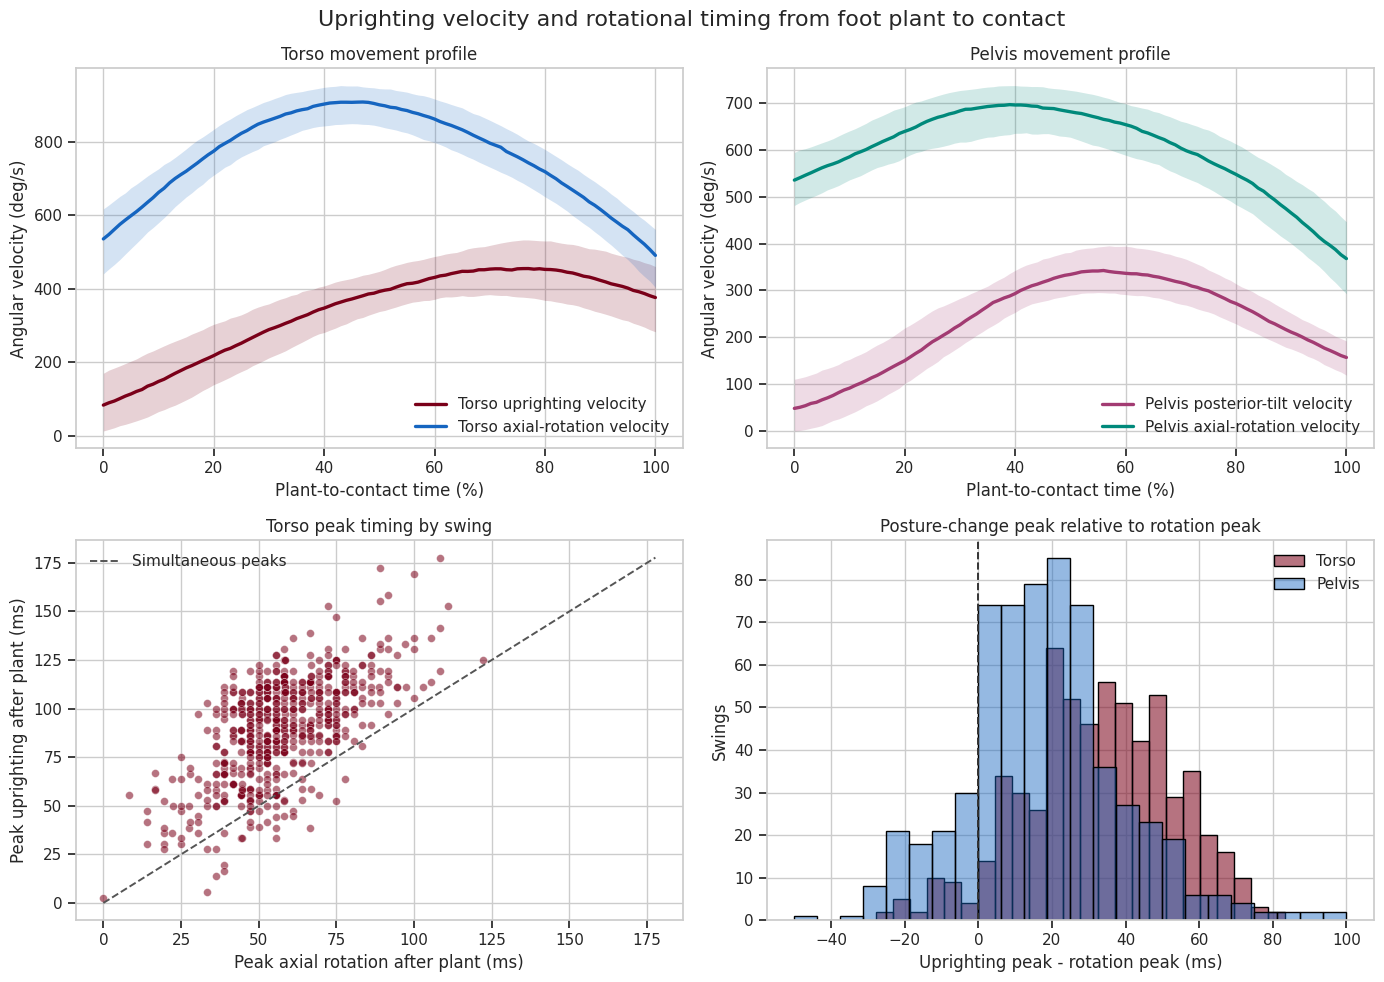

In [10]:
NORMALIZED_TIME = np.linspace(0, 100, 101)


def normalized_swing_curves(group):
    group = group.sort_values("time").reset_index(drop=True)
    plant_time = group["fp_100_time"].iloc[0]
    contact_time = group["contact_time"].iloc[0]

    if classify_event_window(plant_time, contact_time) != "Retained":
        return None

    time = group["time"].to_numpy(dtype=float)
    mask = (time >= plant_time) & (time <= contact_time)
    if mask.sum() < 20:
        return None

    normalized_source = 100 * (
        time[mask] - float(plant_time)
    ) / (float(contact_time) - float(plant_time))
    result = {"session_swing": str(group["session_swing"].iloc[0])}

    for segment in ["torso", "pelvis"]:
        _, angle_rate = filtered_angle_and_rate(
            time,
            group[f"{segment}_angle_x"].to_numpy(dtype=float),
            FILTER_CUTOFF_HZ,
        )
        result[f"{segment}_uprighting"] = np.interp(
            NORMALIZED_TIME,
            normalized_source,
            angle_rate[mask],
        )
        result[f"{segment}_rotation"] = np.interp(
            NORMALIZED_TIME,
            normalized_source,
            group.loc[mask, f"{segment}_angular_velocity_z"].to_numpy(
                dtype=float
            ),
        )

    return result


curve_records = [
    record
    for _, group in kinematics.groupby("session_swing", sort=False)
    if (record := normalized_swing_curves(group)) is not None
]


def curve_matrix(key):
    return np.vstack([record[key] for record in curve_records])


def plot_curve_band(ax, key, label, color):
    matrix = curve_matrix(key)
    median = np.nanmedian(matrix, axis=0)
    lower, upper = np.nanquantile(matrix, [0.25, 0.75], axis=0)
    ax.plot(NORMALIZED_TIME, median, color=color, linewidth=2.4, label=label)
    ax.fill_between(
        NORMALIZED_TIME,
        lower,
        upper,
        color=color,
        alpha=0.18,
        linewidth=0,
    )


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_curve_band(
    axes[0, 0],
    "torso_uprighting",
    "Torso uprighting velocity",
    "#7A0019",
)
plot_curve_band(
    axes[0, 0],
    "torso_rotation",
    "Torso axial-rotation velocity",
    "#1565C0",
)
axes[0, 0].set_title("Torso movement profile")
axes[0, 0].set_xlabel("Plant-to-contact time (%)")
axes[0, 0].set_ylabel("Angular velocity (deg/s)")
axes[0, 0].legend()

plot_curve_band(
    axes[0, 1],
    "pelvis_uprighting",
    "Pelvis posterior-tilt velocity",
    "#A23B72",
)
plot_curve_band(
    axes[0, 1],
    "pelvis_rotation",
    "Pelvis axial-rotation velocity",
    "#00897B",
)
axes[0, 1].set_title("Pelvis movement profile")
axes[0, 1].set_xlabel("Plant-to-contact time (%)")
axes[0, 1].set_ylabel("Angular velocity (deg/s)")
axes[0, 1].legend()

axes[1, 0].scatter(
    swing_features["torso_rotation_peak_ms"],
    swing_features["torso_uprighting_peak_ms"],
    color="#7A0019",
    alpha=0.55,
    s=32,
    edgecolor="white",
    linewidth=0.4,
)
timing_limit = max(
    swing_features["torso_rotation_peak_ms"].max(),
    swing_features["torso_uprighting_peak_ms"].max(),
)
axes[1, 0].plot(
    [0, timing_limit],
    [0, timing_limit],
    color="#555555",
    linestyle="--",
    linewidth=1.4,
    label="Simultaneous peaks",
)
axes[1, 0].set_title("Torso peak timing by swing")
axes[1, 0].set_xlabel("Peak axial rotation after plant (ms)")
axes[1, 0].set_ylabel("Peak uprighting after plant (ms)")
axes[1, 0].legend()

sns.histplot(
    swing_features["torso_uprighting_minus_rotation_ms"],
    bins=24,
    color="#7A0019",
    alpha=0.55,
    label="Torso",
    ax=axes[1, 1],
)
sns.histplot(
    swing_features["pelvis_uprighting_minus_rotation_ms"],
    bins=24,
    color="#1565C0",
    alpha=0.45,
    label="Pelvis",
    ax=axes[1, 1],
)
axes[1, 1].axvline(0, color="#333333", linestyle="--", linewidth=1.4)
axes[1, 1].set_title("Posture-change peak relative to rotation peak")
axes[1, 1].set_xlabel("Uprighting peak - rotation peak (ms)")
axes[1, 1].set_ylabel("Swings")
axes[1, 1].legend()

fig.suptitle(
    "Uprighting velocity and rotational timing from foot plant to contact",
    fontsize=16,
)
fig.tight_layout()

figure_path = (
    PROJECT_ROOT / "figures" / "generated" / "05_uprighting_velocity.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved figure to {figure_path}")

## Exploratory performance relationships

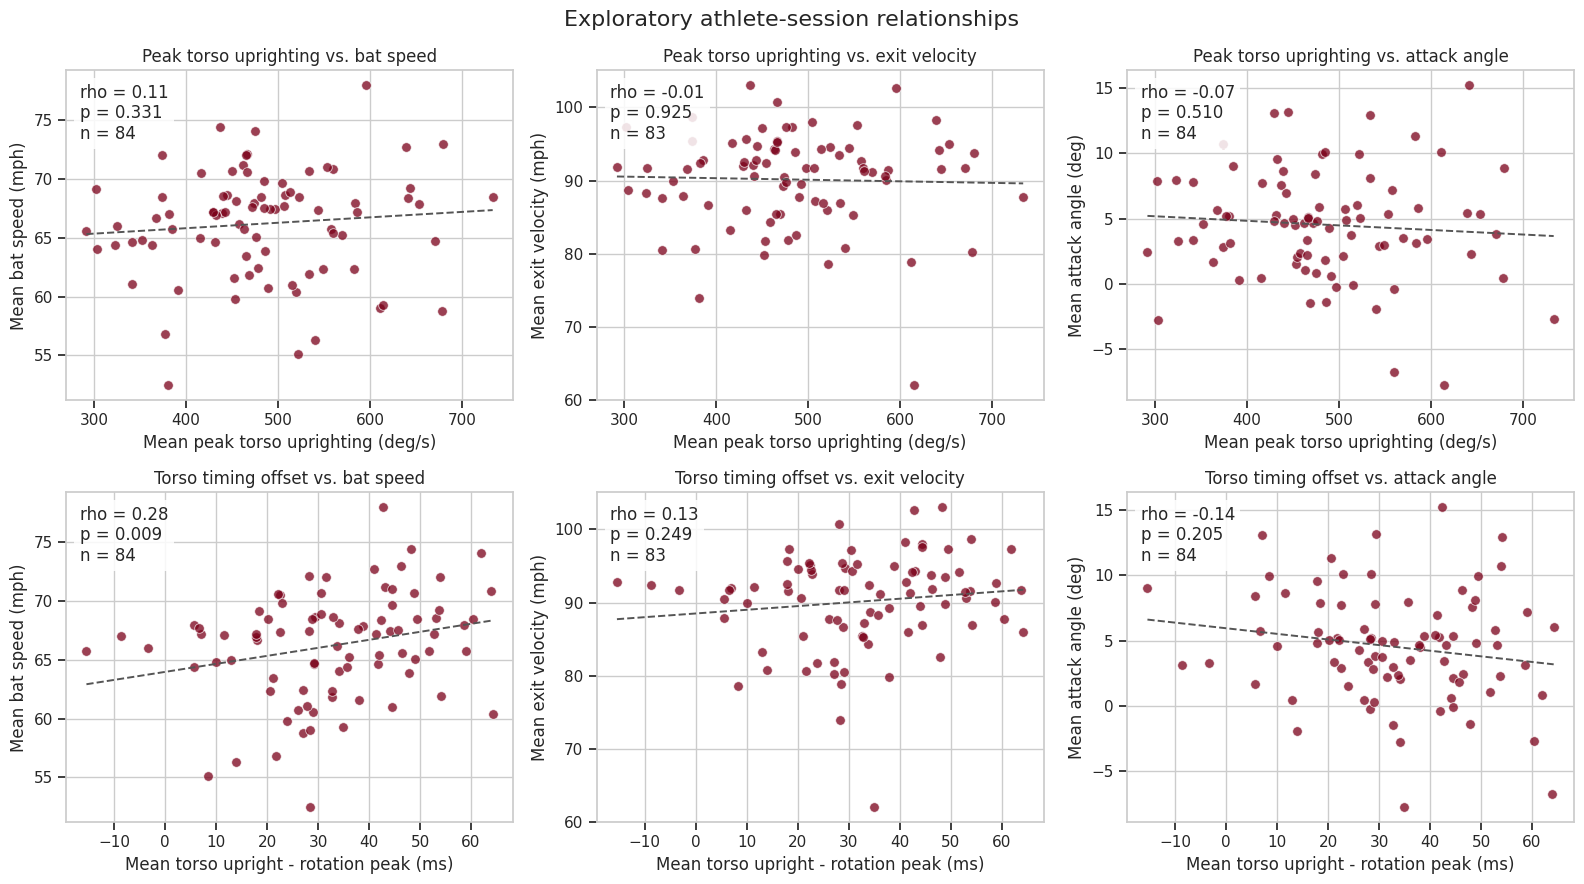

In [11]:
def add_relationship_plot(
    ax,
    data,
    x_column,
    y_column,
    x_label,
    y_label,
    title,
):
    valid = data[[x_column, y_column]].dropna()
    ax.scatter(
        valid[x_column],
        valid[y_column],
        color="#7A0019",
        alpha=0.75,
        edgecolor="white",
        linewidth=0.6,
        s=48,
    )

    if valid[x_column].nunique() >= 2:
        slope, intercept = np.polyfit(valid[x_column], valid[y_column], 1)
        line_x = np.linspace(valid[x_column].min(), valid[x_column].max(), 100)
        ax.plot(
            line_x,
            slope * line_x + intercept,
            color="#555555",
            linestyle="--",
            linewidth=1.4,
        )

    rho, p_value = stats.spearmanr(valid[x_column], valid[y_column])
    ax.text(
        0.03,
        0.96,
        f"rho = {rho:.2f}\np = {p_value:.3f}\nn = {len(valid)}",
        transform=ax.transAxes,
        va="top",
        bbox={"facecolor": "white", "alpha": 0.86, "edgecolor": "none"},
    )
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)


outcome_specs = [
    ("bat_speed_mean_mph", "Mean bat speed (mph)", "Bat speed"),
    ("exit_velo_mean_mph", "Mean exit velocity (mph)", "Exit velocity"),
    ("attack_angle_mean_deg", "Mean attack angle (deg)", "Attack angle"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for column_index, (y_column, y_label, short_title) in enumerate(outcome_specs):
    add_relationship_plot(
        axes[0, column_index],
        session_summary,
        "peak_torso_uprighting_mean_dps",
        y_column,
        "Mean peak torso uprighting (deg/s)",
        y_label,
        f"Peak torso uprighting vs. {short_title.lower()}",
    )
    add_relationship_plot(
        axes[1, column_index],
        session_summary,
        "torso_uprighting_minus_rotation_mean_ms",
        y_column,
        "Mean torso upright - rotation peak (ms)",
        y_label,
        f"Torso timing offset vs. {short_title.lower()}",
    )

fig.suptitle("Exploratory athlete-session relationships", fontsize=16)
fig.tight_layout()
plt.show()

## Interpretation

In [12]:
torso_peak_median = swing_features["peak_torso_uprighting_dps"].median()
torso_timing_median = swing_features[
    "torso_uprighting_minus_rotation_ms"
].median()
pelvis_peak_median = swing_features["peak_pelvis_uprighting_dps"].median()
torso_timing_percentages = (
    swing_features["torso_uprighting_minus_rotation_ms"]
    .map(timing_group)
    .value_counts(normalize=True)
    .mul(100)
)
bat_timing_result = relationship_results.loc[
    relationship_results["relationship"].eq(
        "Torso upright-rotation offset → bat speed"
    )
].iloc[0]

interpretation = f''' 
### What this sample shows

- Across **{len(swing_features):,} retained swings from {swing_features['user'].nunique():,} athletes**, median peak torso uprighting velocity was **{torso_peak_median:.1f} deg/s**. Median peak pelvis posterior-tilt velocity was **{pelvis_peak_median:.1f} deg/s**.
- The median torso uprighting peak occurred **{torso_timing_median:.1f} ms after** the torso axial-rotation peak. Uprighting lagged rotation by more than {COUPLED_WINDOW_MS} ms in **{torso_timing_percentages.get(f'Uprighting lags by >{COUPLED_WINDOW_MS} ms', 0):.1f}%** of swings, fell within ±{COUPLED_WINDOW_MS} ms in **{torso_timing_percentages.get(f'Peaks within ±{COUPLED_WINDOW_MS} ms', 0):.1f}%**, and led by more than {COUPLED_WINDOW_MS} ms in **{torso_timing_percentages.get(f'Uprighting leads by >{COUPLED_WINDOW_MS} ms', 0):.1f}%**.
- Peak torso uprighting speed did not show a clear athlete-session relationship with bat speed, exit velocity, or attack angle in this sample.
- A later torso uprighting peak relative to the rotation peak had a modest positive association with bat speed (**Spearman rho = {bat_timing_result['spearman_rho']:.3f}**, 95% bootstrap CI **{bat_timing_result['ci_low']:.3f} to {bat_timing_result['ci_high']:.3f}**, unadjusted **p = {bat_timing_result['p_value']:.3f}**, FDR-adjusted **q = {bat_timing_result['fdr_q_value']:.3f}**). This is exploratory and should not be read as evidence that delaying uprighting will increase bat speed.
- The 8 Hz and 16 Hz sensitivity runs preserved the rank ordering of peak speeds and changed peak timing only slightly, indicating that the main descriptive results are not an artifact of the single 12 Hz cutoff.

### Coaching interpretation

The useful output is an individualized timing profile, not a universal “stand up less” rule. Two hitters can produce a similar total posture change while reaching it at different speeds and at different points relative to rotation. A sharp or unusually early peak may be worth reviewing alongside bat path, contact location, and video, but this dataset does not establish that any specific velocity or timing value is harmful.
'''

display(Markdown(interpretation))

 
### What this sample shows

- Across **615 retained swings from 93 athletes**, median peak torso uprighting velocity was **484.3 deg/s**. Median peak pelvis posterior-tilt velocity was **353.0 deg/s**.
- The median torso uprighting peak occurred **33.3 ms after** the torso axial-rotation peak. Uprighting lagged rotation by more than 20 ms in **72.8%** of swings, fell within ±20 ms in **26.2%**, and led by more than 20 ms in **1.0%**.
- Peak torso uprighting speed did not show a clear athlete-session relationship with bat speed, exit velocity, or attack angle in this sample.
- A later torso uprighting peak relative to the rotation peak had a modest positive association with bat speed (**Spearman rho = 0.284**, 95% bootstrap CI **0.088 to 0.454**, unadjusted **p = 0.009**, FDR-adjusted **q = 0.053**). This is exploratory and should not be read as evidence that delaying uprighting will increase bat speed.
- The 8 Hz and 16 Hz sensitivity runs preserved the rank ordering of peak speeds and changed peak timing only slightly, indicating that the main descriptive results are not an artifact of the single 12 Hz cutoff.

### Coaching interpretation

The useful output is an individualized timing profile, not a universal “stand up less” rule. Two hitters can produce a similar total posture change while reaching it at different speeds and at different points relative to rotation. A sharp or unusually early peak may be worth reviewing alongside bat path, contact location, and video, but this dataset does not establish that any specific velocity or timing value is harmful.


## Limitations

- The sample is observational and was collected in a controlled pitching-machine environment. Associations do not establish causation.
- Full-signal joint angles are model-derived Euler/Cardan outputs. Their derivatives are sensitive to filtering choices, although the 8 Hz and 16 Hz checks test the stability of the primary 12 Hz result.
- The 80–200 ms event-window rule removes questionable plant/contact timing but also changes the analyzed sample. Results describe retained swings only.
- Athlete-session aggregation reduces repeated-swing pseudoreplication, but most retained athletes contribute a single session, limiting separation of athlete and session effects.
- Six outcome relationships are exploratory and adjusted together for multiple testing. Null or weak sample associations do not prove that a metric is irrelevant for a particular hitter.
- “Uprighting” is positive torso extension under the OpenBiomechanics coordinate convention. It is not synonymous with visual head movement, loss of dynamic balance, or a coaching diagnosis.